# IOOS data 

CDOM data from IOOS is seperated into an East coast region and a West coast region for better processing speeds. 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import geopandas as gpd
from datetime import datetime
import os
from matplotlib import ticker
import datetime as dt
import plotly.express as px
import cmocean as cm
import cmocean.cm as cmo
import matplotlib.gridspec as gridspec
import time
import matplotlib.ticker as mticker

In [ ]:
kwest  = {"min_lon": -131,"max_lon": -111,"min_lat": 19,"max_lat": 53,"min_time": "2000-01-01T00:00:00Z", "max_time": "2025-12-12T00:00:00Z"}
keast  = {"min_lon": -82,"max_lon": -47,"min_lat": 19,"max_lat": 50,"min_time": "2000-01-01T00:00:00Z","max_time": "2025-12-12T00:00:00Z"}


Next, the word 'cdom' is searched on the IOOS ERDDAP server, and any projects that have that keyword as saved to dfs_

In [ ]:
server = "http://erddap.sensors.ioos.us/erddap"
e = ERDDAP(server=server, protocol="tabledap")
url_west = e.get_search_url(search_for="cdom", response="csv",**kwest) #only pull data from within the boundries
url_east = e.get_search_url(search_for="cdom", response="csv",**keast) 
#no cdom in gulf, alaska, or hawaii
dfs_east = pd.read_csv(url_east)
dfs_west = pd.read_csv(url_west)

Next, each project in dfs_ is processed and if it has cdom it's appended to dataframes along with the relevant metadata. 

In [ ]:
dataframes_east_cdom = {}
dataframes_west_cdom = {}

reg_names_cdom = ['dataframes_east_cdom','dataframes_west_cdom']
df_names = ['dfs_east','dfs_west']

for idx2 in range(len(reg_names_cdom)):
    print('region '+reg_names_cdom[idx2])
    for idx, row in globals()[df_names[idx2]].iterrows():
        dataset_id = row['Dataset ID']
        e.dataset_id = dataset_id
        e.variables = ['time', 'latitude', 'longitude', 'cdom ','cdom_qc_agg','z']  #only append these columns
        try:
            print(f"Loading {dataset_id}...")
            df_data = e.to_pandas(index_col="time (UTC)")
            globals()[reg_names_cdom[idx2]][dataset_id] = df_data
            #add these to dataframe to ensure metadata is recorded
            globals()[reg_names_cdom[idx2]][dataset_id]['Dataset ID'] = dataset_id #add a column for dataset id
            globals()[reg_names_cdom[idx2]][dataset_id]['source'] = 'IOOS' #add source column
            globals()[reg_names_cdom[idx2]][dataset_id]['Institution'] = row['Institution'] #add institude column
            globals()[reg_names_cdom[idx2]][dataset_id]['url'] = row['Background Info'] #add link to sensor website
            globals()[reg_names_cdom[idx2]][dataset_id]['experiment'] = row['Title'] #add project to dataset
            time.sleep(1)  # small delay to avoid hammering the server
        except Exception as ex:
            print(f"Failed to load {dataset_id}") #{ex}

Next, rename the columns and remove any suspect or flagged cdom points. 

In [ ]:
for idx2 in range(len(reg_names_cdom)):    
    for dsid, df in globals()[reg_names_cdom[idx2]].items():
        df = df.reset_index()
        df = df.rename(columns={'latitude (degrees_north)': 'lat', 'longitude (degrees_east)': 'lon', 'cdom (microg.L-1)': 'cdom',
            'cdom (1e-9)': 'cdom', 'z (m)': 'depth', 'time (UTC)':'datetime'})
        df.datetime=pd.to_datetime(df.datetime.astype(str),format='mixed')
        df = df[df['cdom_qc_agg'] != 3] #remove all 3s from dataframe i.e suspect points
        df = df[df['cdom_qc_agg'] != 4] #remove all 4s from dataframe i.e. failed points 
        
        globals()[reg_names_cdom[idx2]][dsid] = df  # update the dict

As mentioned in the IOOS chlorophyll code, IOOS datasets have very high temporal resultion and depth resolution sometimes, so reduce to the top 10 meters and to 1 day averages. 

In [ ]:
for idx2 in range(len(reg_names_cdom)):    
    for dsid, df in globals()[reg_names_cdom[idx2]].items(): 
        df=df[(df['depth']>=-10) & (df['depth']<=10)] #only within top 10 meters
        df['date'] = df['datetime'].dt.date
        df = df.drop(columns='datetime')
        df=df.groupby(['date','Dataset ID','source','Institution','url','experiment']).mean() #groupby date and take average
        globals()[reg_names_cdom[idx2]][dsid] = df.reset_index()
        

dataframes_east = pd.concat(dataframes_east_cdom.values(), ignore_index=True)
dataframes_west = pd.concat(dataframes_west_cdom.values(), ignore_index=True)

In [ ]:
dfs=[dataframes_east,dataframes_west]
ioos_cdom = pd.concat(dfs).reset_index(drop=True)
ioos_cdom=ioos_cdom[['date', 'lat', 'lon', 'cdom','depth','Dataset ID', 'source', 'Institution','url', 'experiment',]]
ioos_cdom['date'] = pd.to_datetime(ioos_cdom['date'])
ioos_cdom = ioos_cdom.loc[ioos_cdom['date'] > '2000-01-01'] 
ioos_cdom = ioos_cdom.dropna(subset=['cdom'])
ioos_cdom['depth'] = ioos_cdom['depth'].abs() #make sure depth is not positive

## Plot

In [2]:
ioos = pd.read_excel(r'C:\Users\gianna.milton\Documents\Python\Coastal_chl_final\ioos_cdom_na.xlsx')


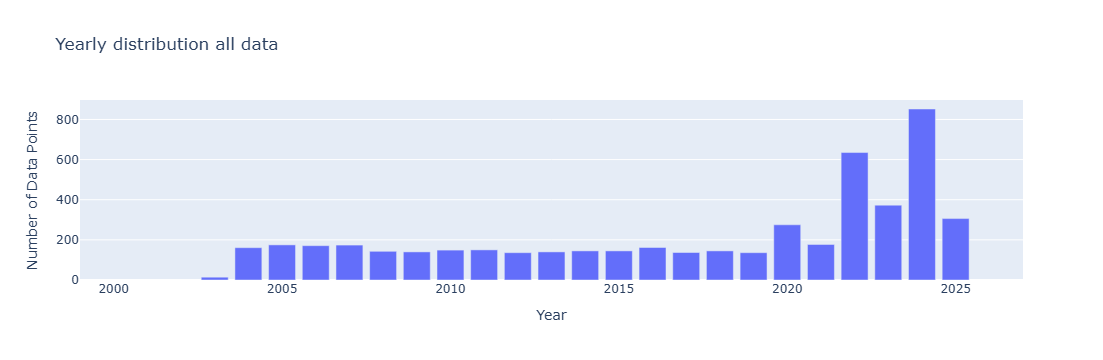

In [3]:
year_test=ioos.copy()
year_test['date'] = pd.to_datetime(year_test['date'])
year_test['year'] = year_test['date'].dt.year
grouped = year_test.groupby(['year']).size().reset_index(name='DataPoints')

# Create bar chart
fig = px.bar(grouped,x='year', y='DataPoints', title='Yearly distribution all data',
             labels={'year': 'Year', 'DataPoints': 'Number of Data Points', 'metadata': 'Metadata'},)
fig.update_xaxes(range=[1999,2027])
fig.update_layout(barmode='stack')  # ensures stacking
fig.show()

Text(0.5, 0.98, 'IOOS CDOM data ')

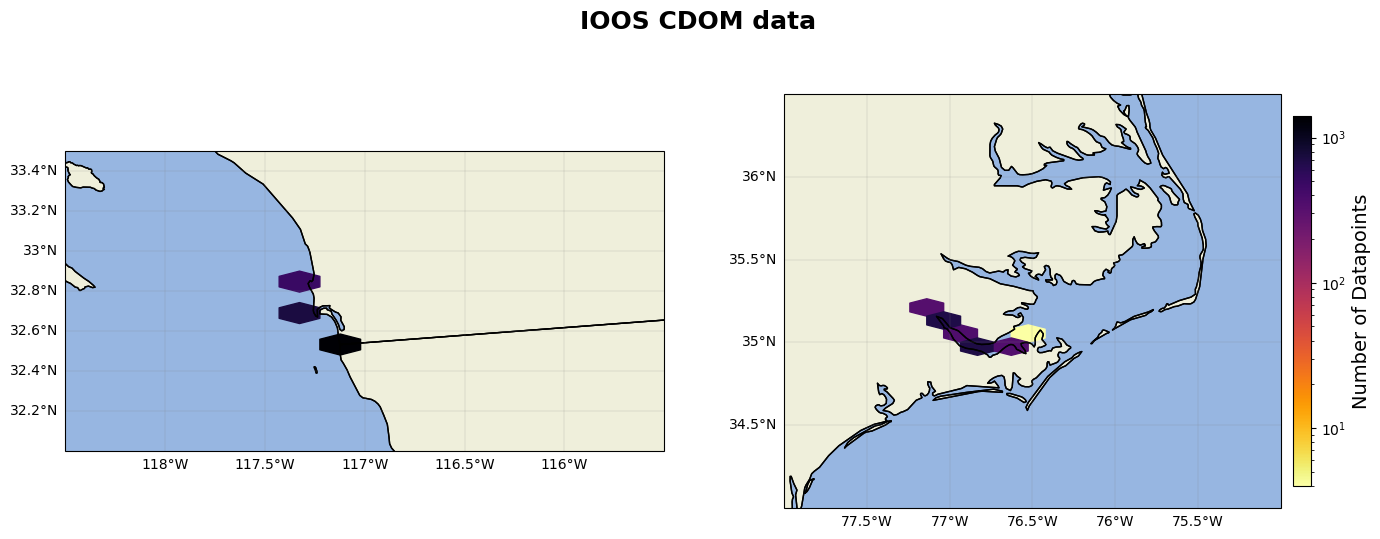

In [14]:
from matplotlib.colors import LogNorm # Important for high-variance data

fig=plt.figure(figsize=(17, 6))
axs1=fig.add_subplot(1,2,1,projection= cartopy.crs.PlateCarree())
axs1.add_feature(cfeature.LAND)
axs1.add_feature(cfeature.OCEAN)
axs1.add_feature(cfeature.COASTLINE)
axs1.add_feature(cfeature.BORDERS)
axs1.add_feature(cfeature.STATES)
hb = axs1.hexbin(year_test.lon, year_test.lat, gridsize=(200,17), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
#cb = plt.colorbar(hb, ax=axs1, orientation='vertical', pad=0.02, shrink=0.8)
#cb.set_label('Number of Datapoints', fontsize=14)
gl=axs1.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs1.set_xlim(-118.5,-115.5)
axs1.set_ylim(32,33.5)

axs2=fig.add_subplot(1,2,2,projection= cartopy.crs.PlateCarree())
axs2.add_feature(cfeature.LAND)
axs2.add_feature(cfeature.OCEAN)
axs2.add_feature(cfeature.COASTLINE)
axs2.add_feature(cfeature.BORDERS)
axs2.add_feature(cfeature.STATES)
hb = axs2.hexbin(year_test.lon, year_test.lat, gridsize=(200,17), cmap='inferno_r', mincnt=1, transform=ccrs.PlateCarree(),norm=LogNorm()) 
cb = plt.colorbar(hb, ax=axs2, orientation='vertical', pad=0.02, shrink=0.8)
cb.set_label('Number of Datapoints', fontsize=14)
gl=axs2.gridlines(linewidth=0.2,color='grey',alpha=0.7,linestyle='-', draw_labels=True, x_inline= False,y_inline=False)
gl.xformatter=LONGITUDE_FORMATTER
gl.yformatter=LATITUDE_FORMATTER
gl.top_labels = False    # Disable top labels
gl.right_labels = False  # Disable right labels
axs2.set_xlim(-78,-75)
axs2.set_ylim(34,36.5)
fig.suptitle("IOOS CDOM data ", fontsize=18, fontweight='bold') # Super title using the figure object
